<a href="https://colab.research.google.com/github/NanditaPatil-dotcom/PhysSAE/blob/main/PhysSAE_Mono_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
import os, time, math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA

# reproducibility
torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(4)

# publication style
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220,
    "font.family": "serif", "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
})

os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# hyperparams
HIDDEN = 40        # PINN hidden width
N_LAYERS = 4       # number of hidden linear layers
LAM = 2e-3
DICT = 128         # SAE dictionary size (overcomplete 3.2x)
SAE_EPOCHS = 500
PINN_ITERS = 4000


# PINN Architecture

In [ ]:
class PINN(nn.Module):
    def __init__(self, out_dim=1, layers=None):
        super().__init__()

        layers = layers or ([2] +[HIDDEN]*N_LAYERS +[out_dim])

        self.net = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1])
             for i in range(len(layers)-1)]
        )

        self.act = nn.Tanh()

        for m in self.net:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

        self._hidden = None

    def forward(self,x,t):
        h = torch.cat([x,t],dim=1)

        for layer in self.net[:-1]:
            h = self.act(layer(h))

        self._hidden = h

        return self.net[-1](h)


# Train PINNs

In [ ]:
def train_pinn(loss_fn, n_iter=PINN_ITERS, log_every=400, tag="pinn",out_dim=1):
    model = PINN(out_dim=out_dim)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = []; t0 = time.time()
    for it in range(n_iter):
        opt.zero_grad()
        loss, parts = loss_fn(model)
        loss.backward(); opt.step()
        hist.append(parts)
        if it % log_every == 0:
            print(f"[{tag}] it {it:5d} | bc {parts[0]:.2e} ic {parts[1]:.2e} f {parts[2]:.2e} | {time.time()-t0:.0f}s")
    print(f"[{tag}] total {time.time()-t0:.0f}s")
    return model, np.array(hist)

# Train on PDE

## Burgers equation

In [ ]:
nu = 0.01/np.pi
def burgers_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1); x_b2 = torch.ones(n_b,1); t_b = torch.rand(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1); u_i = -torch.sin(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    u_b1, u_b2, u_ip = model(x_b1, t_b), model(x_b2, t_b), model(x_i, t_i)
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t + u*u_x - nu*u_xx
    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_ip - u_i)**2).mean()
    l_f  = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/burgers_pinn.pt"):
    pinn_b = PINN(out_dim=1); pinn_b.load_state_dict(torch.load("artifacts/burgers_pinn.pt"))
    hist_b = np.load("artifacts/burgers_hist.npy")
    print("Loaded cached Burgers PINN.")
else:
    pinn_b, hist_b = train_pinn(burgers_loss, tag="burgers")
    torch.save(pinn_b.state_dict(), "artifacts/burgers_pinn.pt")
    np.save("artifacts/burgers_hist.npy", hist_b)


[burgers] it     0 | bc 1.10e-02 ic 5.70e-01 f 1.29e-02 | 0s
[burgers] it   400 | bc 1.10e-03 ic 8.67e-03 f 7.04e-01 | 7s
[burgers] it   800 | bc 4.77e-04 ic 7.83e-04 f 4.56e-01 | 15s
[burgers] it  1200 | bc 3.47e-04 ic 3.61e-04 f 4.19e-01 | 21s
[burgers] it  1600 | bc 1.82e-04 ic 1.95e-04 f 4.21e-01 | 28s
[burgers] it  2000 | bc 1.11e-04 ic 2.32e-04 f 4.05e-01 | 35s
[burgers] it  2400 | bc 2.06e-04 ic 1.84e-04 f 4.13e-01 | 42s
[burgers] it  2800 | bc 4.33e-05 ic 1.25e-04 f 3.53e-01 | 48s
[burgers] it  3200 | bc 1.80e-04 ic 2.56e-04 f 3.65e-01 | 55s
[burgers] it  3600 | bc 1.67e-03 ic 4.62e-04 f 3.67e-01 | 61s
[burgers] total 67s


## allen cahn

In [ ]:
D_AC = 1e-4
def allencahn_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1); x_br = torch.ones(n_b,1)
    x_i = torch.rand(n_i,1)*2-1; t_i = torch.zeros(n_i,1)
    u_i = (x_i**2) * torch.cos(np.pi*x_i)
    x_f = torch.rand(n_f,1)*2-1; t_f = torch.rand(n_f,1)
    # periodic BC: u(-1,t)=u(1,t) and u_x(-1,t)=u_x(1,t)
    xbl_g, xbr_g = x_bl.clone().requires_grad_(True), x_br.clone().requires_grad_(True)
    u_bl, u_br = model(xbl_g, t_b), model(xbr_g, t_b)
    u_bl_x = torch.autograd.grad(u_bl, xbl_g, torch.ones_like(u_bl), create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br, xbr_g, torch.ones_like(u_br), create_graph=True)[0]
    l_bc = ((u_bl-u_br)**2).mean() + ((u_bl_x-u_br_x)**2).mean()
    u_ip = model(x_i, t_i); l_ic = ((u_ip - u_i)**2).mean()
    xfg, tfg = x_f.clone().requires_grad_(True), t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u, tfg, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg, torch.ones_like(u_x), create_graph=True)[0]
    r = u_t - D_AC*u_xx + 5.0*u**3 - 5.0*u
    l_f = (r**2).mean()
    return 100*l_bc + 100*l_ic + l_f, (l_bc.item(), l_ic.item(), l_f.item())

if os.path.exists("artifacts/allencahn_pinn.pt"):
    pinn_a = PINN(out_dim=1); pinn_a.load_state_dict(torch.load("artifacts/allencahn_pinn.pt"))
    hist_a = np.load("artifacts/allencahn_hist.npy")
    print("Loaded cached Allen-Cahn PINN.")
else:
    pinn_a, hist_a = train_pinn(allencahn_loss, tag="allencahn")
    torch.save(pinn_a.state_dict(), "artifacts/allencahn_pinn.pt")
    np.save("artifacts/allencahn_hist.npy", hist_a)


[allencahn] it     0 | bc 3.69e-02 ic 1.12e-01 f 1.38e-01 | 0s
[allencahn] it   400 | bc 2.12e-03 ic 2.07e-02 f 1.16e+00 | 6s
[allencahn] it   800 | bc 8.14e-04 ic 3.23e-03 f 1.07e+00 | 13s
[allencahn] it  1200 | bc 5.53e-04 ic 1.31e-03 f 1.03e+00 | 20s
[allencahn] it  1600 | bc 1.75e-04 ic 8.39e-04 f 9.82e-01 | 27s
[allencahn] it  2000 | bc 3.41e-04 ic 5.95e-04 f 9.79e-01 | 35s
[allencahn] it  2400 | bc 1.46e-04 ic 7.61e-04 f 1.08e+00 | 42s
[allencahn] it  2800 | bc 8.46e-05 ic 7.73e-04 f 9.64e-01 | 50s
[allencahn] it  3200 | bc 1.03e-04 ic 7.99e-04 f 1.01e+00 | 58s
[allencahn] it  3600 | bc 8.15e-05 ic 9.58e-04 f 9.20e-01 | 65s
[allencahn] total 73s


## heat

In [ ]:
def heat_loss(model):
    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -torch.ones(n_b,1)
    x_b2 =  torch.ones(n_b,1)
    t_b = torch.rand(n_b,1)
    u_b1 = model(x_b1, t_b)
    u_b2 = model(x_b2, t_b)
    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)
    u_i_true = torch.exp(-5*x_i**2)
    u_i = model(x_i, t_i)
    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    u = model(xfg, tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x,xfg,torch.ones_like(u_x),create_graph=True)[0]

    r = u_t - u_xx

    l_bc = (u_b1**2).mean() + (u_b2**2).mean()
    l_ic = ((u_i - u_i_true)**2).mean()
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

if os.path.exists("artifacts/heat_pinn.pt"):
    pinn_h = PINN(out_dim=1)
    pinn_h.load_state_dict(torch.load("artifacts/heat_pinn.pt"))
    hist_h = np.load("artifacts/heat_hist.npy")
    print("Loaded cached Heat PINN.")
else:
    pinn_h, hist_h = train_pinn(heat_loss,tag="heat")
    torch.save(pinn_h.state_dict(),"artifacts/heat_pinn.pt")
    np.save("artifacts/heat_hist.npy",hist_h)

[heat] it     0 | bc 1.51e-01 ic 3.47e-01 f 1.63e-01 | 0s
[heat] it   400 | bc 5.80e-04 ic 2.92e-03 f 3.62e-01 | 7s
[heat] it   800 | bc 4.20e-04 ic 7.76e-04 f 1.70e-01 | 14s
[heat] it  1200 | bc 2.65e-04 ic 4.71e-04 f 9.77e-02 | 21s
[heat] it  1600 | bc 1.42e-04 ic 2.70e-04 f 5.95e-02 | 28s
[heat] it  2000 | bc 8.54e-05 ic 1.85e-04 f 3.60e-02 | 35s
[heat] it  2400 | bc 6.82e-05 ic 1.51e-04 f 2.13e-02 | 42s
[heat] it  2800 | bc 5.51e-05 ic 6.39e-05 f 1.72e-02 | 49s
[heat] it  3200 | bc 2.23e-04 ic 7.96e-05 f 1.40e-02 | 56s
[heat] it  3600 | bc 1.08e-05 ic 3.01e-05 f 1.22e-02 | 63s
[heat] total 70s


## schrodinger

In [ ]:
def schrodinger_loss(model):

    n_b, n_i, n_f = 100, 100, 2500
    x_b1 = -5*torch.ones(n_b,1)
    x_b2 =  5*torch.ones(n_b,1)
    t_b  = torch.rand(n_b,1)
    uv_b1 = model(x_b1,t_b)
    uv_b2 = model(x_b2,t_b)
    u_b1 = uv_b1[:,0:1]
    v_b1 = uv_b1[:,1:2]
    u_b2 = uv_b2[:,0:1]
    v_b2 = uv_b2[:,1:2]
    x_i = -5 + 10*torch.rand(n_i,1)
    t_i = torch.zeros(n_i,1)

    uv_i = model(x_i,t_i)

    u_i = uv_i[:,0:1]
    v_i = uv_i[:,1:2]

    eta = 2.0
    v0  = 2.0

    amp0 = eta / torch.cosh(eta*x_i)

    u_true = amp0 * torch.cos(v0*x_i)
    v_true = amp0 * torch.sin(v0*x_i)
    x_f = -5 + 10*torch.rand(n_f,1)
    t_f = torch.rand(n_f,1)
    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)
    uv = model(xfg,tfg)
    u = uv[:,0:1]
    v = uv[:,1:2]

    u_t = torch.autograd.grad(u, tfg,torch.ones_like(u),create_graph=True)[0]
    v_t = torch.autograd.grad(v, tfg,torch.ones_like(v),create_graph=True)[0]
    u_x = torch.autograd.grad(u, xfg,torch.ones_like(u),create_graph=True)[0]
    v_x = torch.autograd.grad(v, xfg,torch.ones_like(v),create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, xfg,torch.ones_like(u_x),create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, xfg,torch.ones_like(v_x),create_graph=True)[0]
    amp2 = u*u + v*v
    r_u = u_t + 0.5*v_xx + amp2*v
    r_v = v_t - 0.5*u_xx - amp2*u
    l_bc = ((u_b1**2).mean()+ (v_b1**2).mean()+ (u_b2**2).mean()+ (v_b2**2).mean())
    l_ic = (((u_i-u_true)**2).mean()+ ((v_i-v_true)**2).mean())
    l_f = ((r_u**2).mean()+ (r_v**2).mean())
    total = 100*l_bc + 100*l_ic + l_f

    return total, (l_bc.item(),l_ic.item(),l_f.item())


if os.path.exists("artifacts/schrodinger_pinn.pt"):
    pinn_s = PINN(out_dim=2)
    pinn_s.load_state_dict(torch.load("artifacts/schrodinger_pinn.pt"))
    hist_s = np.load("artifacts/schrodinger_hist.npy")
    print("Loaded cached Schrödinger PINN.")

else:
    pinn_s, hist_s = train_pinn(schrodinger_loss,tag="schrodinger",out_dim=2)
    torch.save(pinn_s.state_dict(),"artifacts/schrodinger_pinn.pt")
    np.save("artifacts/schrodinger_hist.npy",hist_s)

[schrodinger] it     0 | bc 8.39e-01 ic 5.51e-01 f 2.95e-02 | 0s
[schrodinger] it   400 | bc 3.20e-04 ic 1.38e-02 f 9.08e-01 | 11s
[schrodinger] it   800 | bc 4.36e-04 ic 2.86e-03 f 3.67e-01 | 22s
[schrodinger] it  1200 | bc 2.40e-04 ic 1.44e-03 f 2.66e-01 | 32s
[schrodinger] it  1600 | bc 8.81e-05 ic 7.71e-04 f 2.03e-01 | 43s
[schrodinger] it  2000 | bc 3.48e-05 ic 3.90e-04 f 1.74e-01 | 53s
[schrodinger] it  2400 | bc 4.61e-05 ic 2.20e-04 f 1.59e-01 | 64s
[schrodinger] it  2800 | bc 5.30e-05 ic 1.93e-04 f 1.32e-01 | 74s
[schrodinger] it  3200 | bc 4.06e-05 ic 1.20e-04 f 1.17e-01 | 84s
[schrodinger] it  3600 | bc 1.07e-04 ic 1.24e-04 f 9.44e-02 | 95s
[schrodinger] total 105s


## convection

In [ ]:
def convection_loss(model, beta):

    n_b, n_i, n_f = 100, 100, 2500

    # periodic BC
    t_b = torch.rand(n_b,1)
    x_bl = -torch.ones(n_b,1)
    x_br =  torch.ones(n_b,1)
    u_bl = model(x_bl, t_b)
    u_br = model(x_br, t_b)

    # periodic derivative BC
    xbl_g = x_bl.clone().requires_grad_(True)
    xbr_g = x_br.clone().requires_grad_(True)

    u_bl_g = model(xbl_g, t_b)
    u_br_g = model(xbr_g, t_b)

    u_bl_x = torch.autograd.grad(u_bl_g,xbl_g,torch.ones_like(u_bl_g),create_graph=True)[0]
    u_br_x = torch.autograd.grad(u_br_g,xbr_g,torch.ones_like(u_br_g),create_graph=True)[0]
    l_bc = ((u_bl - u_br)**2).mean() + ((u_bl_x - u_br_x)**2).mean()

    # initial condition

    x_i = 2*torch.rand(n_i,1) - 1
    t_i = torch.zeros(n_i,1)

    u_true = torch.sin(np.pi*x_i)

    u_i = model(x_i,t_i)

    l_ic = ((u_i - u_true)**2).mean()

    # residual points

    x_f = 2*torch.rand(n_f,1) - 1
    t_f = torch.rand(n_f,1)

    xfg = x_f.clone().requires_grad_(True)
    tfg = t_f.clone().requires_grad_(True)

    u = model(xfg,tfg)
    u_t = torch.autograd.grad(u,tfg,torch.ones_like(u),create_graph=True)[0]
    u_x = torch.autograd.grad(u,xfg,torch.ones_like(u),create_graph=True)[0]

    r = u_t + beta*u_x
    l_f = (r**2).mean()
    total = 100*l_bc + 100*l_ic + l_f
    return total, (l_bc.item(),l_ic.item(),l_f.item())

In [ ]:
BETAS = [1,50]

conv_models = {}
conv_hists  = {}

for beta in BETAS:

    fname_model = f"artifacts/convection_beta{beta}.pt"
    fname_hist  = f"artifacts/convection_beta{beta}_hist.npy"

    if os.path.exists(fname_model):

        model = PINN(out_dim=1)
        model.load_state_dict(torch.load(fname_model))
        hist = np.load(fname_hist)
        print(f"Loaded cached convection PINN beta={beta}")

    else:

        loss_fn = lambda m, b=beta: convection_loss(m,b)
        model, hist = train_pinn(loss_fn,tag=f"conv_beta{beta}")
        torch.save(model.state_dict(),fname_model)
        np.save(fname_hist,hist)

    conv_models[beta] = model
    conv_hists[beta]  = hist

[conv_beta1] it     0 | bc 1.21e-01 ic 4.36e-01 f 3.79e-02 | 0s
[conv_beta1] it   400 | bc 1.18e-03 ic 3.92e-03 f 8.08e-01 | 5s
[conv_beta1] it   800 | bc 1.22e-03 ic 5.82e-04 f 6.82e-01 | 9s
[conv_beta1] it  1200 | bc 1.07e-03 ic 5.07e-04 f 5.13e-01 | 14s
[conv_beta1] it  1600 | bc 8.30e-04 ic 3.42e-04 f 3.84e-01 | 19s
[conv_beta1] it  2000 | bc 3.82e-04 ic 1.86e-04 f 2.68e-01 | 24s
[conv_beta1] it  2400 | bc 1.39e-04 ic 6.72e-05 f 2.01e-01 | 29s
[conv_beta1] it  2800 | bc 4.97e-04 ic 3.83e-05 f 1.33e-01 | 34s
[conv_beta1] it  3200 | bc 2.79e-04 ic 8.62e-05 f 1.02e-01 | 39s
[conv_beta1] it  3600 | bc 3.13e-04 ic 2.67e-05 f 6.95e-02 | 45s
[conv_beta1] total 50s
[conv_beta50] it     0 | bc 1.87e-01 ic 6.61e-01 f 1.26e+02 | 0s
[conv_beta50] it   400 | bc 2.07e-02 ic 3.13e-01 f 3.90e+00 | 5s
[conv_beta50] it   800 | bc 4.25e-02 ic 1.10e-01 f 1.87e+00 | 11s
[conv_beta50] it  1200 | bc 8.73e-04 ic 5.13e-02 f 1.42e+00 | 16s
[conv_beta50] it  1600 | bc 3.62e-02 ic 3.75e-02 f 2.38e+00 | 21s
[c

# Evaluate the PINN

In [ ]:
nx, nt = 256, 100
xs = torch.linspace(-1, 1, nx).reshape(-1,1)
ts = torch.linspace(0, 1, nt).reshape(-1,1)
X, T = torch.meshgrid(xs.squeeze(), ts.squeeze(), indexing='ij')
XF, TF = X.reshape(-1,1), T.reshape(-1,1)
np.save("artifacts/grid_x.npy", xs.numpy().squeeze())
np.save("artifacts/grid_t.npy", ts.numpy().squeeze())

def eval_pinn_and_hidden(model):
    with torch.no_grad():
        U = model(XF, TF).reshape(nx, nt).numpy()
        H = model._hidden.detach().reshape(nx, nt, HIDDEN).numpy()
    return U, H

def eval_schrodinger_and_hidden(model):

    with torch.no_grad():
        UV = model(XF,TF)
        U = UV[:,0].reshape(nx,nt).numpy()
        V = UV[:,1].reshape(nx,nt).numpy()
        H = (model._hidden.detach().reshape(nx,nt,HIDDEN).numpy())
    return U,V,H

U_b, H_b = eval_pinn_and_hidden(pinn_b)
np.save("artifacts/burgers_U.npy", U_b)
np.save("artifacts/burgers_H.npy", H_b)

U_a, H_a = eval_pinn_and_hidden(pinn_a)
np.save("artifacts/allencahn_U.npy", U_a)
np.save("artifacts/allencahn_H.npy", H_a)

U_h, H_h = eval_pinn_and_hidden(pinn_h)
np.save("artifacts/heat_U.npy",U_h)
np.save("artifacts/heat_H.npy",H_h)

U_s, V_s, H_s = eval_schrodinger_and_hidden(pinn_s)
np.save("artifacts/schrodinger_u.npy", U_s)
np.save("artifacts/schrodinger_v.npy", V_s)
np.save("artifacts/schrodinger_H.npy", H_s)
AMP_s = np.sqrt(U_s**2 + V_s**2)
np.save("artifacts/schrodinger_amp.npy",AMP_s)
PHI_s = np.arctan2(V_s, U_s)
np.save("artifacts/schrodinger_phi.npy",PHI_s)

# Successful convection (beta=1)
U_c1, H_c1 = eval_pinn_and_hidden(conv_models[1])
np.save("artifacts/convection_beta1_U.npy", U_c1)
np.save("artifacts/convection_beta1_H.npy", H_c1)

# Failed convection (beta=50)
U_c50, H_c50 = eval_pinn_and_hidden(conv_models[50])
np.save("artifacts/convection_beta50_U.npy", U_c50)
np.save("artifacts/convection_beta50_H.npy", H_c50)

print(f"Burgers   U range [{U_b.min():.3f}, {U_b.max():.3f}], H shape {H_b.shape}")
print(f"AllenCahn U range [{U_a.min():.3f}, {U_a.max():.3f}], H shape {H_a.shape}")
print(f"Heat     U range "f"[{U_h.min():.3f}, {U_h.max():.3f}], "f"H shape {H_h.shape}")
print("Schrodinger:", U_s.shape, V_s.shape, H_s.shape)
print(f"Conv β=1   U range [{U_c1.min():.3f}, {U_c1.max():.3f}], "f"H shape {H_c1.shape}")
print(f"Conv β=50  U range [{U_c50.min():.3f}, {U_c50.max():.3f}], "f"H shape {H_c50.shape}")


Burgers   U range [-0.975, 0.984], H shape (256, 100, 40)
AllenCahn U range [-0.919, 0.073], H shape (256, 100, 40)
Heat     U range [-0.011, 0.993], H shape (256, 100, 40)
Schrodinger: (256, 100) (256, 100) (256, 100, 40)
Conv β=1   U range [-1.026, 0.991], H shape (256, 100, 40)
Conv β=50  U range [-0.903, 0.868], H shape (256, 100, 40)


# Sparse AutoEncoder

In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in=HIDDEN, d_dict=DICT):
        super().__init__()
        self.enc = nn.Linear(d_in, d_dict, bias=True)
        self.dec = nn.Linear(d_dict, d_in, bias=True)
        with torch.no_grad():
            self.dec.weight.copy_(self.dec.weight / (self.dec.weight.norm(dim=0, keepdim=True) + 1e-8))
        self.b_pre = nn.Parameter(torch.zeros(d_in))
    def encode(self, h): return torch.relu(self.enc(h - self.b_pre))
    def decode(self, z): return self.dec(z) + self.b_pre
    def forward(self, h):
        z = self.encode(h); return self.decode(z), z

def train_sae(H, n_epochs=SAE_EPOCHS, batch=4096, lr=1e-3, lam=LAM, verbose=True):
    print(lam);
    H_t = torch.from_numpy(H).float()
    N, d_in = H_t.shape
    sae = SparseAutoencoder(d_in=d_in, d_dict=DICT)
    opt = torch.optim.Adam(sae.parameters(), lr=lr)
    losses = []
    for ep in range(n_epochs):
        perm = torch.randperm(N)
        sums = [0.,0.,0.,0.]; nb = 0
        for s in range(0, N, batch):
            idx = perm[s:s+batch]; h = H_t[idx]
            h_hat, z = sae(h)
            recon = ((h_hat - h)**2).sum(dim=1).mean()
            l1 = z.abs().sum(dim=1).mean()
            loss = recon + lam * l1
            opt.zero_grad(); loss.backward(); opt.step()
            with torch.no_grad():
                w = sae.dec.weight
                sae.dec.weight.copy_(w / (w.norm(dim=0, keepdim=True) + 1e-8))
            l0 = (z > 1e-6).float().sum(dim=1).mean().item()
            for j,v in enumerate([loss.item(), recon.item(), l1.item(), l0]): sums[j]+=v
            nb += 1
        sums = [s/nb for s in sums]; losses.append(sums)
        if verbose and (ep % 100 == 0 or ep == n_epochs-1):
            print(f"  ep {ep:4d} | recon {sums[1]:.3e} | L1 {sums[2]:.2f} | L0 {sums[3]:.2f}")
    return sae, np.array(losses)

# Normalization

In [ ]:
def normalize(H_flat):
    mu = H_flat.mean(0, keepdims=True)
    sd = H_flat.std(0, keepdims=True) + 1e-6
    return (H_flat - mu) / sd, mu, sd

# Flatten Burgers hidden activations
H_b_flat = H_b.reshape(-1, HIDDEN)
H_a_flat = H_a.reshape(-1, HIDDEN)
H_h_flat = H_h.reshape(-1, HIDDEN)
H_s_flat = H_s.reshape(-1, HIDDEN)
H_c1_flat  = H_c1.reshape(-1, HIDDEN)
H_c50_flat = H_c50.reshape(-1, HIDDEN)

# Normalize
H_b_n, mu_b, sd_b = normalize(H_b_flat)
H_a_n, mu_a, sd_a = normalize(H_a_flat)
H_h_n, mu_h, sd_h = normalize(H_h_flat)
H_s_n, mu_s, sd_s = normalize(H_s_flat)
H_c1_n,  mu_c1,  sd_c1  = normalize(H_c1_flat)
H_c50_n, mu_c50, sd_c50 = normalize(H_c50_flat)

print(f"Burgers   activations: {H_b_n.shape}, mean(|h|)={np.abs(H_b_n).mean():.3f}")
print(f"AllenCahn activations: {H_a_n.shape}, mean(|h|)={np.abs(H_a_n).mean():.3f}")
print(f"Heat activations: {H_h_n.shape}, mean(|h|)={np.abs(H_h_n).mean():.3f}")
print(f"Schrodinger activations: "f"{H_s_n.shape}, "f"mean(|h|)={np.abs(H_s_n).mean():.3f}")
print(f"Conv β=1 activations: "f"{H_c1_n.shape}, "f"mean(|h|)={np.abs(H_c1_n).mean():.3f}")
print(f"Conv β=50 activations: "f"{H_c50_n.shape}, "f"mean(|h|)={np.abs(H_c50_n).mean():.3f}")

Burgers   activations: (25600, 40), mean(|h|)=0.817
AllenCahn activations: (25600, 40), mean(|h|)=0.787
Heat activations: (25600, 40), mean(|h|)=0.716
Schrodinger activations: (25600, 40), mean(|h|)=0.802
Conv β=1 activations: (25600, 40), mean(|h|)=0.827
Conv β=50 activations: (25600, 40), mean(|h|)=0.406


# Train all SAEs

In [ ]:
# Train / Load SAEs
def get_sae(tag, H_norm):
    path = f"artifacts/{tag}_sae.pt"

    if os.path.exists(path):
        sae = SparseAutoencoder()
        sae.load_state_dict(torch.load(path))
        print(f"Loaded SAE: {tag}")
        return sae

    print(f"Training SAE: {tag}")
    sae, _ = train_sae(H_norm)
    torch.save(sae.state_dict(), path)
    return sae


# Load / train one SAE for each PDE
sae_b   = get_sae("burgers", H_b_n)
sae_a   = get_sae("allencahn", H_a_n)
sae_h   = get_sae("heat", H_h_n)
sae_s   = get_sae("schrodinger", H_s_n)
sae_c1  = get_sae("convection_beta1", H_c1_n)
sae_c50 = get_sae("convection_beta50", H_c50_n)


# Encode hidden activations
def encode_hidden(sae, H_norm):
    with torch.no_grad():
        Z = sae.encode(torch.from_numpy(H_norm).float()).numpy()
    return Z.reshape(nx, nt, DICT)


Z_b   = encode_hidden(sae_b, H_b_n)
Z_a   = encode_hidden(sae_a, H_a_n)
Z_h   = encode_hidden(sae_h, H_h_n)
Z_s   = encode_hidden(sae_s, H_s_n)
Z_c1  = encode_hidden(sae_c1, H_c1_n)
Z_c50 = encode_hidden(sae_c50, H_c50_n)


print("Latent codes computed successfully.")
print(f"Burgers      : {Z_b.shape}")
print(f"Allen-Cahn   : {Z_a.shape}")
print(f"Heat         : {Z_h.shape}")
print(f"Schrodinger  : {Z_s.shape}")
print(f"Conv β=1     : {Z_c1.shape}")
print(f"Conv β=50    : {Z_c50.shape}")

Training SAE: burgers
0.002
  ep    0 | recon 4.998e+01 | L1 30.92 | L0 64.30
  ep  100 | recon 4.459e-02 | L1 32.92 | L0 63.44
  ep  200 | recon 1.888e-02 | L1 28.19 | L0 63.19
  ep  300 | recon 1.087e-02 | L1 24.00 | L0 62.41
  ep  400 | recon 7.156e-03 | L1 20.59 | L0 61.25
  ep  499 | recon 5.088e-03 | L1 17.96 | L0 60.04
Training SAE: allencahn
0.002
  ep    0 | recon 5.024e+01 | L1 26.00 | L0 62.46
  ep  100 | recon 4.823e-02 | L1 30.37 | L0 60.76
  ep  200 | recon 1.964e-02 | L1 26.34 | L0 60.47
  ep  300 | recon 1.109e-02 | L1 22.79 | L0 59.49
  ep  400 | recon 7.268e-03 | L1 19.63 | L0 58.15
  ep  499 | recon 5.225e-03 | L1 17.04 | L0 56.99
Training SAE: heat
0.002
  ep    0 | recon 4.615e+01 | L1 24.50 | L0 66.80
  ep  100 | recon 4.272e-02 | L1 27.72 | L0 64.67
  ep  200 | recon 1.835e-02 | L1 24.12 | L0 63.85
  ep  300 | recon 1.074e-02 | L1 20.74 | L0 62.71
  ep  400 | recon 7.228e-03 | L1 17.90 | L0 61.18
  ep  499 | recon 5.064e-03 | L1 15.25 | L0 58.93
Training SAE: sch

# Ground Concept mapping


In [ ]:
def concepts_burgers(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (shock)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "|u_xx| (curvature)": np.abs(u_xx),
        "dist to x=0": np.tile(np.abs(xs).reshape(-1,1), (1, nt)),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }

def concepts_allencahn(U, xs, ts):
    dx = xs[1]-xs[0]; dt = ts[1]-ts[0]
    u_x = np.gradient(U, dx, axis=0); u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (interface)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "u (signed)": U,
        "u^3 (reaction)": U**3,
        "interface (exp(-u^2/0.1))": np.exp(-U**2/0.1),
        "t (time)": np.tile(ts.reshape(1,-1), (nx, 1)),
    }
def concepts_heat(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    u_xx = np.gradient(u_x, dx, axis=0)
    nx, nt = U.shape
    return {
        "|u|": np.abs(U),
        "|u_x| (gradient)": np.abs(u_x),
        "|u_t|": np.abs(u_t),
        "|u_xx| (curvature)": np.abs(u_xx),
        "t (time)": np.tile(ts.reshape(1,-1),(nx,1))
    }
def concepts_schrodinger(U, V, AMP, PHI, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    v_x = np.gradient(V, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    v_t = np.gradient(V, dt, axis=1)
    h_x = np.sqrt(u_x**2 + v_x**2)
    h_t = np.sqrt(u_t**2 + v_t**2)
    nx, nt = U.shape
    return {
        "|h| (amplitude)" : AMP,
        "u (real)" : U,
        "v (imag)" : V,
        "|h_x| (wave-front)" : h_x,
        "|h_t| (temporal)" : h_t,
        "phi (phase)" : PHI,
        "t (time)" : np.tile(ts.reshape(1,-1),(nx,1))
    }

def concepts_convection(U, xs, ts):
    dx = xs[1] - xs[0]
    dt = ts[1] - ts[0]
    u_x = np.gradient(U, dx, axis=0)
    u_t = np.gradient(U, dt, axis=1)
    nx, nt = U.shape
    X = np.tile(xs.reshape(-1,1), (1,nt))
    T = np.tile(ts.reshape(1,-1), (nx,1))
    return {
        "|u|" : np.abs(U),
        "|u_x| (transport front)" : np.abs(u_x),
        "|u_t|" : np.abs(u_t),
        "u (signed)" : U,
        "x position" : X,
        "t (time)" : T,
        "characteristic (x-t)" : X - T,
        "characteristic (x-50t)" : X - 50*T
        }

# Convert grid to NumPy
xs_np = xs.numpy().squeeze()
ts_np = ts.numpy().squeeze()
#schrodinger
xs_s = np.linspace(-5, 5, U_s.shape[0])
ts_s = np.linspace(0, 1, U_s.shape[1])

C_b = concepts_burgers(U_b, xs_np, ts_np)
C_a = concepts_allencahn(U_a, xs_np, ts_np)
C_h = concepts_heat(U_h, xs_np, ts_np)
C_s = concepts_schrodinger(U_s,V_s,AMP_s,PHI_s,np.linspace(-5,5,U_s.shape[0]),np.linspace(0,1,U_s.shape[1]))
C_c1 = concepts_convection(U_c1,xs_np,ts_np)
C_c50 = concepts_convection(U_c50,xs_np,ts_np)

np.savez("artifacts/burgers_concepts.npz", **C_b)
np.savez("artifacts/allencahn_concepts.npz", **C_a)
np.savez("artifacts/heat_concepts.npz",**C_h)
np.savez("artifacts/schrodinger_concepts.npz",**C_s)
np.savez("artifacts/convection_beta1_concepts.npz",**C_c1)
np.savez("artifacts/convection_beta50_concepts.npz",**C_c50)

print("Burgers concepts  :", list(C_b.keys()))
print("AllenCahn concepts:", list(C_a.keys()))
print("Heat concepts     :", list(C_h.keys()))
print("Schrodinger concepts:",list(C_s.keys()))
print("Conv β=1 concepts:",list(C_c1.keys()))
print("Conv β=50 concepts:",list(C_c50.keys()))

Burgers concepts  : ['|u|', '|u_x| (shock)', '|u_t|', 'u (signed)', '|u_xx| (curvature)', 'dist to x=0', 't (time)']
AllenCahn concepts: ['|u|', '|u_x| (interface)', '|u_t|', 'u (signed)', 'u^3 (reaction)', 'interface (exp(-u^2/0.1))', 't (time)']
Heat concepts     : ['|u|', '|u_x| (gradient)', '|u_t|', '|u_xx| (curvature)', 't (time)']
Schrodinger concepts: ['|h| (amplitude)', 'u (real)', 'v (imag)', '|h_x| (wave-front)', '|h_t| (temporal)', 'phi (phase)', 't (time)']
Conv β=1 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)', 'characteristic (x-50t)']
Conv β=50 concepts: ['|u|', '|u_x| (transport front)', '|u_t|', 'u (signed)', 'x position', 't (time)', 'characteristic (x-t)', 'characteristic (x-50t)']


# Atom-concept alignment matrix

In [ ]:
# Alignment Matrices (SAE & PCA)

def alignment(Z_field, concepts):
    """Compute atom/component vs concept Pearson correlation matrix."""

    names = list(concepts.keys())
    K = Z_field.shape[-1]

    A = np.zeros((K, len(names)))

    for k in range(K):
        z = Z_field[..., k].reshape(-1)

        if z.std() < 1e-8:
            continue

        z = (z - z.mean()) / (z.std() + 1e-12)

        for j, name in enumerate(names):
            c = concepts[name].reshape(-1)
            c = (c - c.mean()) / (c.std() + 1e-12)

            A[k, j] = np.mean(z * c)

    return A, names


# ---------- SAE alignment ----------

A_b, names_b     = alignment(Z_b, C_b)
A_a, names_a     = alignment(Z_a, C_a)
A_h, names_h     = alignment(Z_h, C_h)
A_s, names_s     = alignment(Z_s, C_s)
A_c1, names_c1   = alignment(Z_c1, C_c1)
A_c50, names_c50 = alignment(Z_c50, C_c50)

# ---------- Best concept for every SAE atom ----------

best_idx_b   = np.argmax(np.abs(A_b), axis=1)
best_idx_a   = np.argmax(np.abs(A_a), axis=1)
best_idx_h   = np.argmax(np.abs(A_h), axis=1)
best_idx_s   = np.argmax(np.abs(A_s), axis=1)
best_idx_c1  = np.argmax(np.abs(A_c1), axis=1)
best_idx_c50 = np.argmax(np.abs(A_c50), axis=1)

best_concept_b   = [names_b[i] for i in best_idx_b]
best_concept_a   = [names_a[i] for i in best_idx_a]
best_concept_h   = [names_h[i] for i in best_idx_h]
best_concept_s   = [names_s[i] for i in best_idx_s]
best_concept_c1  = [names_c1[i] for i in best_idx_c1]
best_concept_c50 = [names_c50[i] for i in best_idx_c50]

# ---------- PCA Features ----------

def pca_features(H):
    """Compute PCA features and reshape to (nx, nt, n_components)."""
    P = PCA(n_components=HIDDEN).fit_transform(H)
    return P.reshape(nx, nt, -1)


# PCA latent features
P_b   = pca_features(H_b_n)
P_a   = pca_features(H_a_n)
P_h   = pca_features(H_h_n)
P_s   = pca_features(H_s_n)
P_c1  = pca_features(H_c1_n)
P_c50 = pca_features(H_c50_n)


# PCA alignment matrices
A_pca_b, _   = alignment(P_b, C_b)
A_pca_a, _   = alignment(P_a, C_a)
A_pca_h, _   = alignment(P_h, C_h)
A_pca_s, _   = alignment(P_s, C_s)
A_pca_c1, _  = alignment(P_c1, C_c1)
A_pca_c50, _ = alignment(P_c50, C_c50)

print("SAE and PCA alignment matrices computed.")


SAE and PCA alignment matrices computed.


# Monosemanticity Metrics

In [ ]:
def monosemanticity_scores(A):
    """
    Compute monosemanticity score for each atom/component.

    m_k = max_j |A[k,j]|

    Returns
    -------
    mk : ndarray of shape (num_atoms,)
        Maximum absolute concept correlation for every atom.
    """
    return np.max(np.abs(A), axis=1)


# ---------- SAE ----------

mk_b   = monosemanticity_scores(A_b)
mk_a   = monosemanticity_scores(A_a)
mk_h   = monosemanticity_scores(A_h)
mk_s   = monosemanticity_scores(A_s)
mk_c1  = monosemanticity_scores(A_c1)
mk_c50 = monosemanticity_scores(A_c50)


# ---------- PCA ----------

mk_pca_b   = monosemanticity_scores(A_pca_b)
mk_pca_a   = monosemanticity_scores(A_pca_a)
mk_pca_h   = monosemanticity_scores(A_pca_h)
mk_pca_s   = monosemanticity_scores(A_pca_s)
mk_pca_c1  = monosemanticity_scores(A_pca_c1)
mk_pca_c50 = monosemanticity_scores(A_pca_c50)


print("Monosemanticity scores computed.")

print(f"Burgers      : {mk_b.shape}")
print(f"Allen-Cahn   : {mk_a.shape}")
print(f"Heat         : {mk_h.shape}")
print(f"Schrodinger  : {mk_s.shape}")
print(f"Conv β=1     : {mk_c1.shape}")
print(f"Conv β=50    : {mk_c50.shape}")

Monosemanticity scores computed.
Burgers      : (128,)
Allen-Cahn   : (128,)
Heat         : (128,)
Schrodinger  : (128,)
Conv β=1     : (128,)
Conv β=50    : (128,)


# Monosemantic Atom Fraction

In [ ]:
THRESHOLD = 0.6

def monosemantic_fraction(mk, threshold=THRESHOLD):
    """
    Fraction of atoms/components with monosemanticity
    score greater than the specified threshold.
    """
    return np.mean(mk > threshold)


# ---------- SAE ----------

frac_b   = monosemantic_fraction(mk_b)
frac_a   = monosemantic_fraction(mk_a)
frac_h   = monosemantic_fraction(mk_h)
frac_s   = monosemantic_fraction(mk_s)
frac_c1  = monosemantic_fraction(mk_c1)
frac_c50 = monosemantic_fraction(mk_c50)


# ---------- PCA ----------

frac_pca_b   = monosemantic_fraction(mk_pca_b)
frac_pca_a   = monosemantic_fraction(mk_pca_a)
frac_pca_h   = monosemantic_fraction(mk_pca_h)
frac_pca_s   = monosemantic_fraction(mk_pca_s)
frac_pca_c1  = monosemantic_fraction(mk_pca_c1)
frac_pca_c50 = monosemantic_fraction(mk_pca_c50)


# ---------- Print Results ----------

print(f"{'PDE':18s} {'SAE':>10s} {'PCA':>10s}")
print("-" * 40)

print(f"{'Burgers':18s} {frac_b:10.3f} {frac_pca_b:10.3f}")
print(f"{'Allen-Cahn':18s} {frac_a:10.3f} {frac_pca_a:10.3f}")
print(f"{'Heat':18s} {frac_h:10.3f} {frac_pca_h:10.3f}")
print(f"{'Schrodinger':18s} {frac_s:10.3f} {frac_pca_s:10.3f}")
print(f"{'Conv β=1':18s} {frac_c1:10.3f} {frac_pca_c1:10.3f}")
print(f"{'Conv β=50':18s} {frac_c50:10.3f} {frac_pca_c50:10.3f}")

PDE                       SAE        PCA
----------------------------------------
Burgers                 0.406      0.075
Allen-Cahn              0.367      0.025
Heat                    0.258      0.075
Schrodinger             0.633      0.075
Conv β=1                0.719      0.075
Conv β=50               0.648      0.025


# Feature Density

In [ ]:
EPSILON = 1e-6

def feature_density(Z, eps=EPSILON):
    """
    Compute feature density for each atom/component.

    density_k = fraction of grid points where z_k > eps

    Parameters
    ----------
    Z : ndarray (nx, nt, K)

    Returns
    -------
    density : ndarray (K,)
    """
    Z_flat = Z.reshape(-1, Z.shape[-1])
    return np.mean(Z_flat > eps, axis=0)


# ---------- SAE ----------

density_b   = feature_density(Z_b)
density_a   = feature_density(Z_a)
density_h   = feature_density(Z_h)
density_s   = feature_density(Z_s)
density_c1  = feature_density(Z_c1)
density_c50 = feature_density(Z_c50)


# ---------- PCA ----------

density_pca_b   = feature_density(P_b)
density_pca_a   = feature_density(P_a)
density_pca_h   = feature_density(P_h)
density_pca_s   = feature_density(P_s)
density_pca_c1  = feature_density(P_c1)
density_pca_c50 = feature_density(P_c50)


print("Feature density computed.")

print(f"Burgers      : {density_b.shape}")
print(f"Allen-Cahn   : {density_a.shape}")
print(f"Heat         : {density_h.shape}")
print(f"Schrodinger  : {density_s.shape}")
print(f"Conv β=1     : {density_c1.shape}")
print(f"Conv β=50    : {density_c50.shape}")

Feature density computed.
Burgers      : (128,)
Allen-Cahn   : (128,)
Heat         : (128,)
Schrodinger  : (128,)
Conv β=1     : (128,)
Conv β=50    : (128,)


# Summary Statistics


In [ ]:
def summary_statistics(mk, density, fraction):
    """
    Compute summary statistics for a single PDE.
    """
    return {
        "mean_mk": np.mean(mk),
        "median_mk": np.median(mk),
        "std_mk": np.std(mk),

        "fraction_gt_0.6": fraction,

        "mean_density": np.mean(density),
        "median_density": np.median(density),
        "std_density": np.std(density),
    }


# ---------- SAE ----------

summary_sae = {
    "Burgers": summary_statistics(mk_b, density_b, frac_b),
    "Allen-Cahn": summary_statistics(mk_a, density_a, frac_a),
    "Heat": summary_statistics(mk_h, density_h, frac_h),
    "Schrodinger": summary_statistics(mk_s, density_s, frac_s),
    "Convection β=1": summary_statistics(mk_c1, density_c1, frac_c1),
    "Convection β=50": summary_statistics(mk_c50, density_c50, frac_c50),
}


# ---------- PCA ----------

summary_pca = {
    "Burgers": summary_statistics(mk_pca_b, density_pca_b, frac_pca_b),
    "Allen-Cahn": summary_statistics(mk_pca_a, density_pca_a, frac_pca_a),
    "Heat": summary_statistics(mk_pca_h, density_pca_h, frac_pca_h),
    "Schrodinger": summary_statistics(mk_pca_s, density_pca_s, frac_pca_s),
    "Convection β=1": summary_statistics(mk_pca_c1, density_pca_c1, frac_pca_c1),
    "Convection β=50": summary_statistics(mk_pca_c50, density_pca_c50, frac_pca_c50),
}


# ---------- Print Summary ----------

for pde in summary_sae:

    print(f"\n{pde}")
    print("-" * len(pde))

    print("SAE")
    for k, v in summary_sae[pde].items():
        print(f"  {k:18s}: {v:.4f}")

    print("PCA")
    for k, v in summary_pca[pde].items():
        print(f"  {k:18s}: {v:.4f}")


Burgers
-------
SAE
  mean_mk           : 0.5705
  median_mk         : 0.5564
  std_mk            : 0.1319
  fraction_gt_0.6   : 0.4062
  mean_density      : 0.4691
  median_density    : 0.4611
  std_density       : 0.1239
PCA
  mean_mk           : 0.2034
  median_mk         : 0.1325
  std_mk            : 0.1820
  fraction_gt_0.6   : 0.0750
  mean_density      : 0.5015
  median_density    : 0.4993
  std_density       : 0.0292

Allen-Cahn
----------
SAE
  mean_mk           : 0.5123
  median_mk         : 0.5426
  std_mk            : 0.1772
  fraction_gt_0.6   : 0.3672
  mean_density      : 0.4450
  median_density    : 0.4245
  std_density       : 0.1423
PCA
  mean_mk           : 0.1544
  median_mk         : 0.0820
  std_mk            : 0.1638
  fraction_gt_0.6   : 0.0250
  mean_density      : 0.5024
  median_density    : 0.4989
  std_density       : 0.0351

Heat
----
SAE
  mean_mk           : 0.4761
  median_mk         : 0.4754
  std_mk            : 0.1735
  fraction_gt_0.6   : 0.2578
 

(array([ 6., 11.,  8., 12.,  4.,  5.,  9.,  7.,  4.,  5.,  3.,  5.,  4.,
         3.,  3.,  5.,  0.,  2.,  5.,  4.,  5.,  0.,  2.,  2.,  0.,  5.,
         2.,  1.,  4.,  2.]),
 array([0.        , 0.02976953, 0.05953906, 0.08930859, 0.11907812,
        0.14884766, 0.17861719, 0.20838672, 0.23815625, 0.26792578,
        0.29769531, 0.32746484, 0.35723437, 0.38700391, 0.41677344,
        0.44654297, 0.4763125 , 0.50608203, 0.53585156, 0.56562109,
        0.59539062, 0.62516016, 0.65492969, 0.68469922, 0.71446875,
        0.74423828, 0.77400781, 0.80377734, 0.83354687, 0.86331641,
        0.89308594]),
 <BarContainer object of 30 artists>)

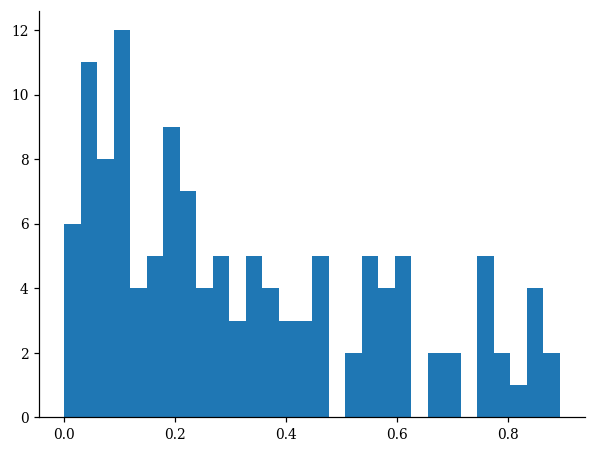

In [ ]:
plt.hist(density_c50, bins=30)

(array([ 1.,  1.,  2.,  2.,  3.,  2.,  6.,  3.,  6.,  6.,  4., 13.,  7.,
         9.,  8.,  6., 10.,  7.,  3.,  7.,  3.,  6.,  2.,  5.,  0.,  0.,
         4.,  0.,  0.,  2.]),
 array([0.20726563, 0.22617708, 0.24508854, 0.264     , 0.28291146,
        0.30182292, 0.32073438, 0.33964583, 0.35855729, 0.37746875,
        0.39638021, 0.41529167, 0.43420313, 0.45311458, 0.47202604,
        0.4909375 , 0.50984896, 0.52876042, 0.54767188, 0.56658333,
        0.58549479, 0.60440625, 0.62331771, 0.64222917, 0.66114063,
        0.68005208, 0.69896354, 0.717875  , 0.73678646, 0.75569792,
        0.77460938]),
 <BarContainer object of 30 artists>)

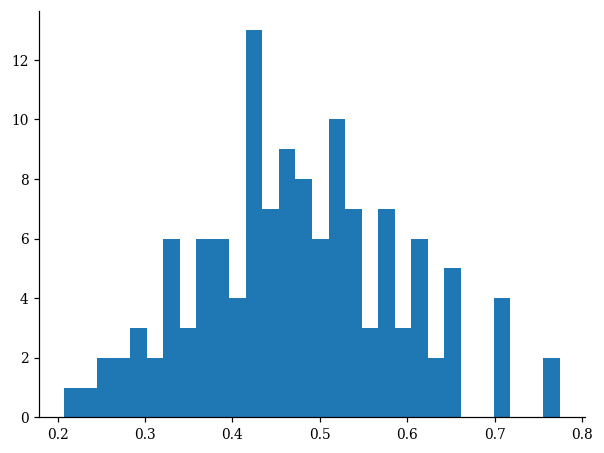

In [ ]:
plt.hist(density_c1, bins=30)

# Plots

## Plot 1-2: Monosemanticity Histograms

In [ ]:
def plot_mk_histograms(mk_sae, mk_pca, title):

    fig, ax = plt.subplots(1, 2, figsize=(9,3.5))

    ax[0].hist(mk_sae, bins=20)
    ax[0].axvline(
    0.6,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    alpha=0.9,
    label=r"$m_k=0.6$ threshold"
   )

    ax[0].set_title(f"{title} (SAE)")
    ax[0].set_xlabel("Monosemanticity Score")
    ax[0].set_ylabel("Number of Atoms")

    ax[1].hist(mk_pca, bins=20)
    ax[1].axvline(
    0.6,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    alpha=0.9,
    label=r"$m_k=0.6$ threshold"
    )
    ax[1].set_title(f"{title} (PCA)")
    ax[1].set_xlabel("Monosemanticity Score")

    ax[0].axvspan(0.6, 1.0, color="red", alpha=0.08)
    ax[1].axvspan(0.6, 1.0, color="red", alpha=0.08)

    plt.tight_layout()
    plt.show()

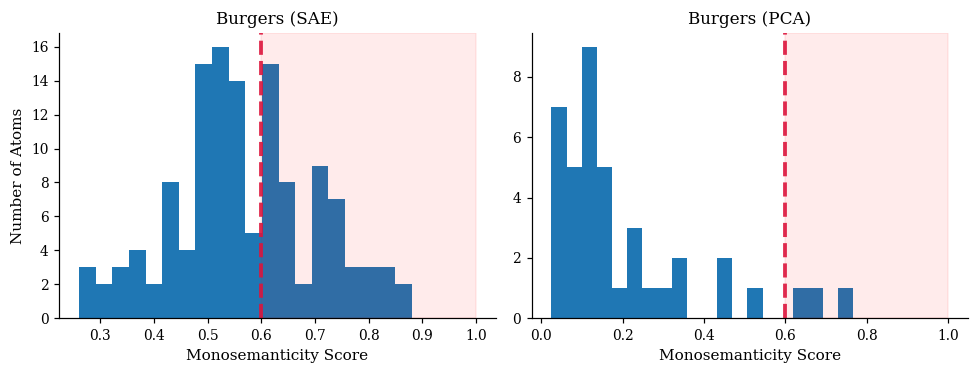

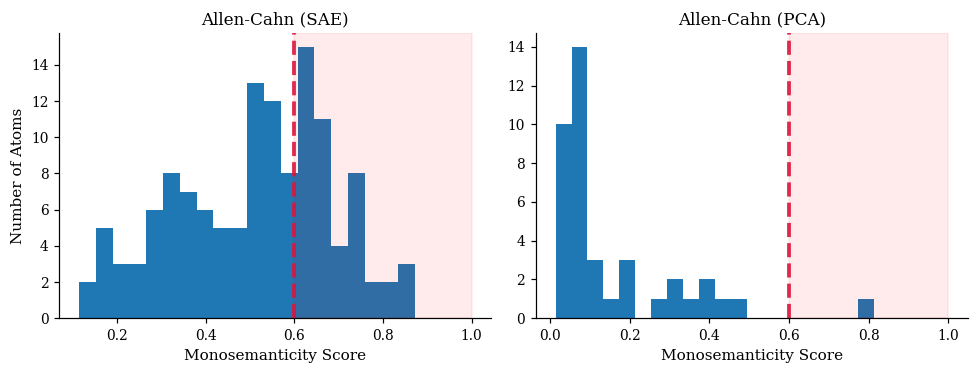

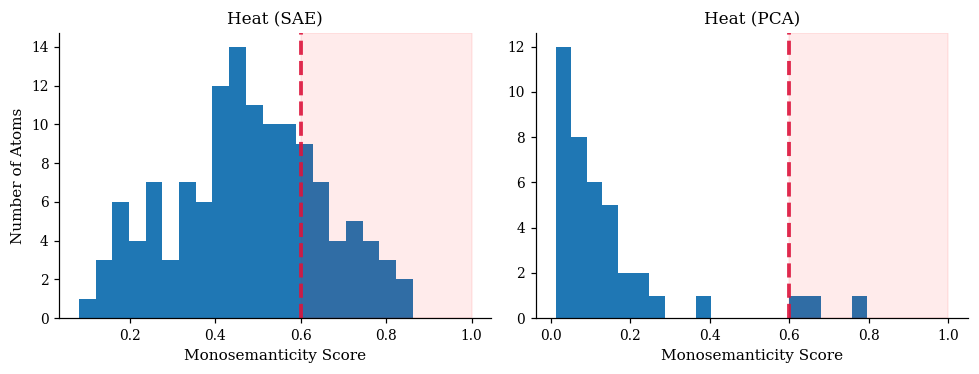

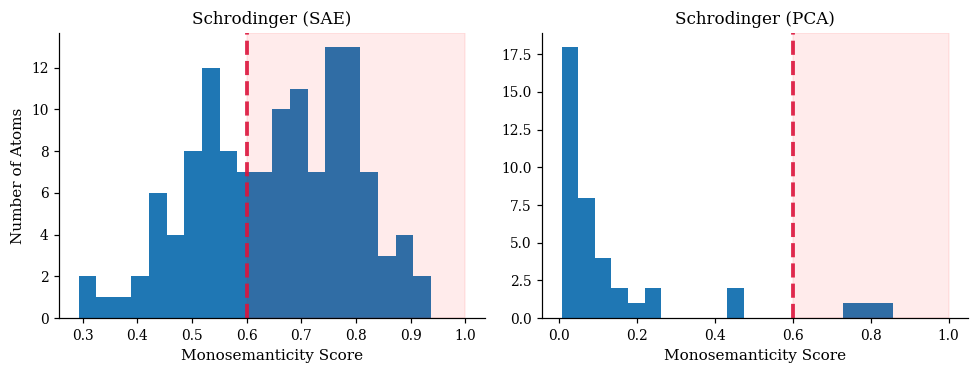

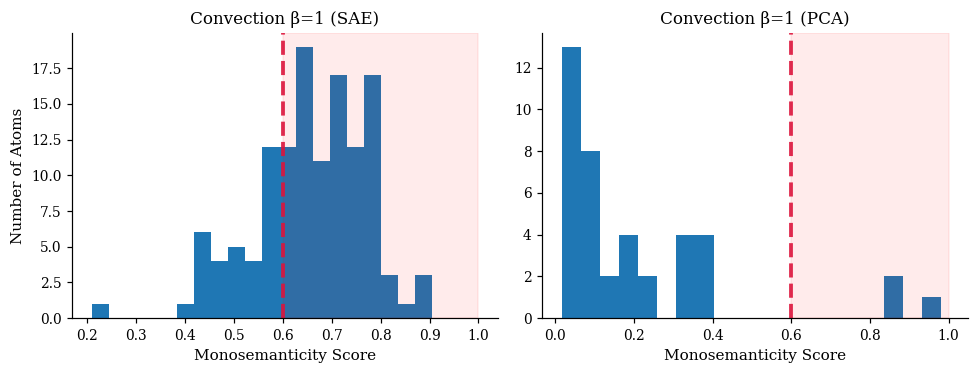

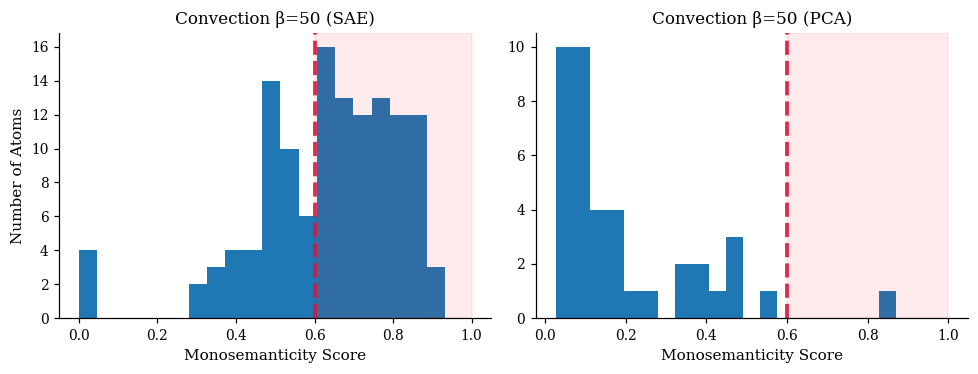

In [ ]:
plot_mk_histograms(mk_b, mk_pca_b, "Burgers")
plot_mk_histograms(mk_a, mk_pca_a, "Allen-Cahn")
plot_mk_histograms(mk_h, mk_pca_h, "Heat")
plot_mk_histograms(mk_s, mk_pca_s, "Schrodinger")
plot_mk_histograms(mk_c1, mk_pca_c1, "Convection β=1")
plot_mk_histograms(mk_c50, mk_pca_c50, "Convection β=50")

## Plot 3-4: Feature Density Histograms

In [ ]:
def plot_density_histograms(density_sae, density_pca, title):

    fig, ax = plt.subplots(1,2, figsize=(9,3.5))

    ax[0].hist(density_sae, bins=20)
    ax[0].set_title(f"{title} (SAE)")
    ax[0].set_xlabel("Feature Density")
    ax[0].set_ylabel("Number of Atoms")

    ax[1].hist(density_pca, bins=20)
    ax[1].set_title(f"{title} (PCA)")
    ax[1].set_xlabel("Feature Density")

    plt.tight_layout()
    plt.show()

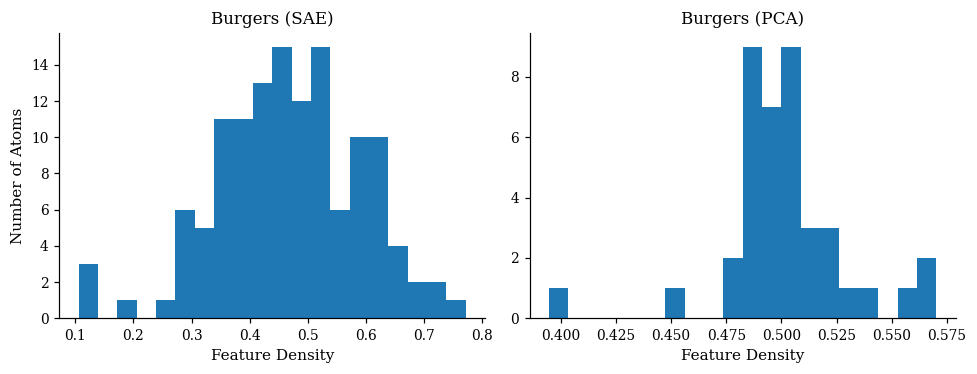

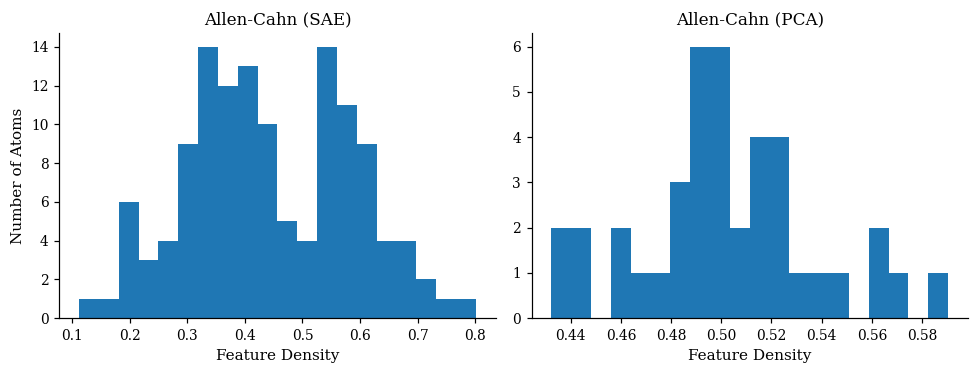

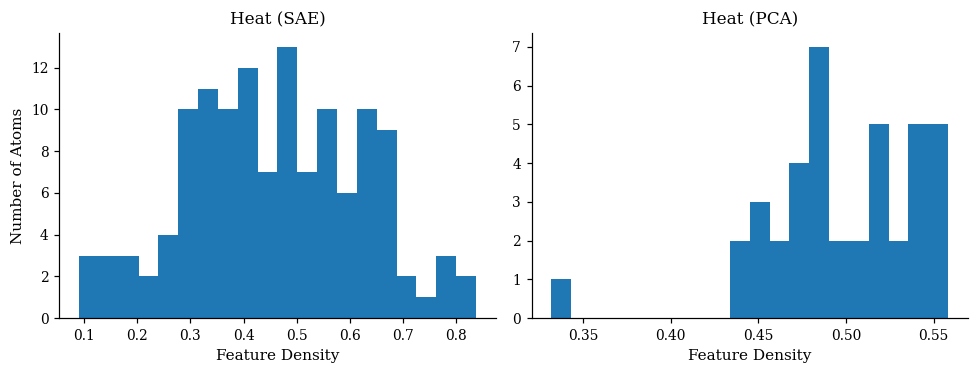

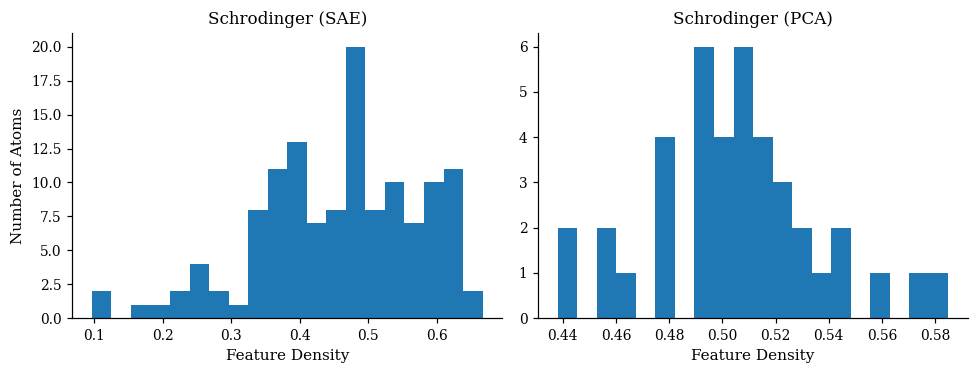

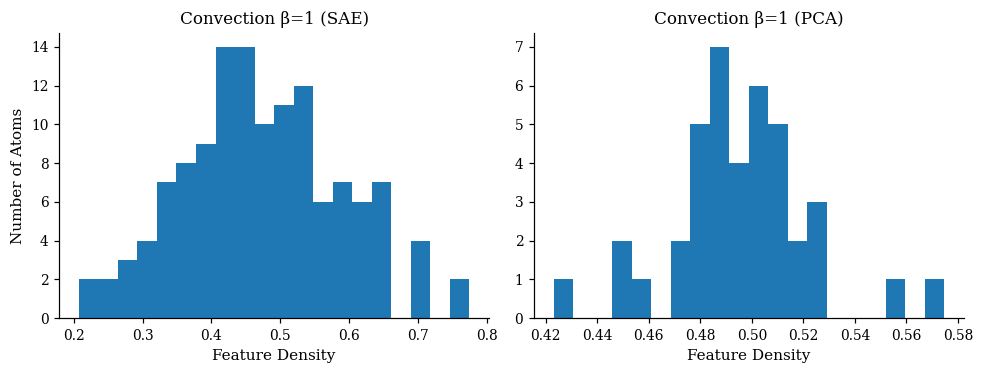

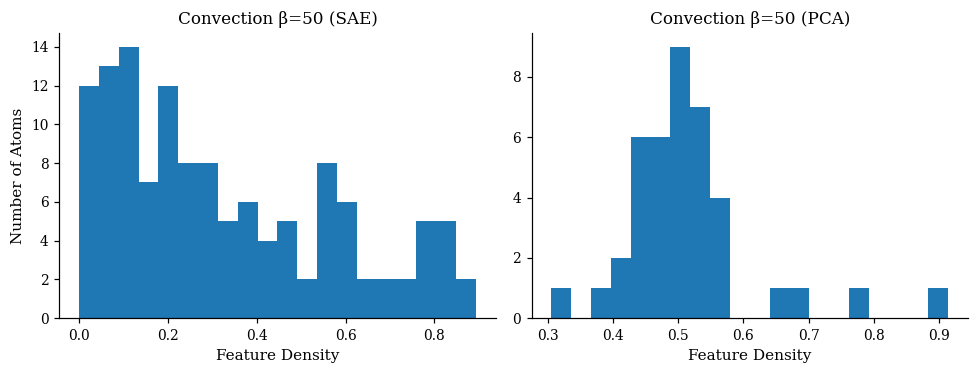

In [ ]:
plot_density_histograms(density_b, density_pca_b, "Burgers")
plot_density_histograms(density_a, density_pca_a, "Allen-Cahn")
plot_density_histograms(density_h, density_pca_h, "Heat")
plot_density_histograms(density_s, density_pca_s, "Schrodinger")
plot_density_histograms(density_c1, density_pca_c1, "Convection β=1")
plot_density_histograms(density_c50, density_pca_c50, "Convection β=50")


## Plot 5: Fraction > 0.6

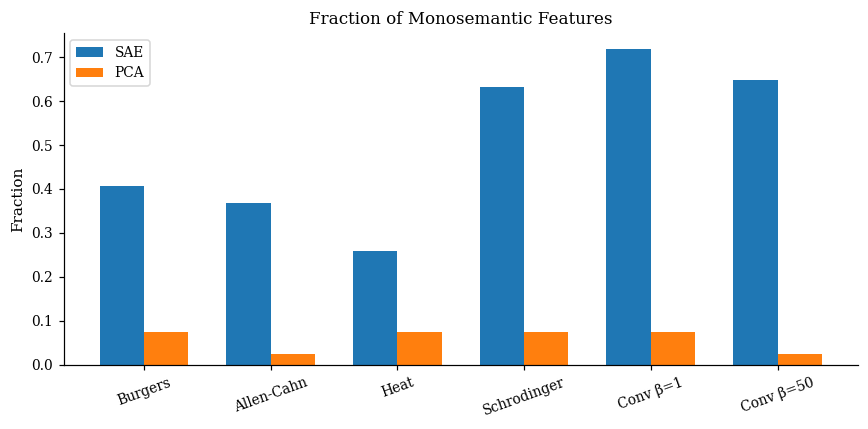

In [ ]:
labels = [
    "Burgers",
    "Allen-Cahn",
    "Heat",
    "Schrodinger",
    "Conv β=1",
    "Conv β=50"
]

sae = [
    frac_b,
    frac_a,
    frac_h,
    frac_s,
    frac_c1,
    frac_c50
]

pca = [
    frac_pca_b,
    frac_pca_a,
    frac_pca_h,
    frac_pca_s,
    frac_pca_c1,
    frac_pca_c50
]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,4))

plt.bar(x-w/2, sae, width=w, label="SAE")
plt.bar(x+w/2, pca, width=w, label="PCA")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Fraction")
plt.title("Fraction of Monosemantic Features")
plt.legend()

plt.tight_layout()
plt.show()

## Plot 6: Mean Feature Density

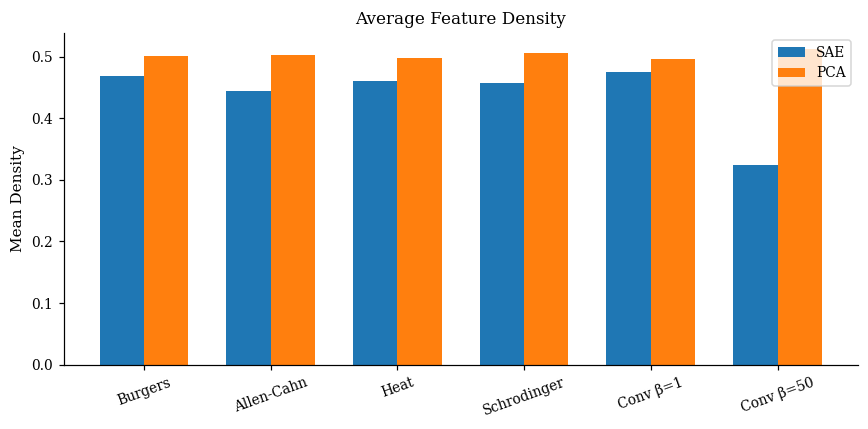

In [ ]:
sae = [
    np.mean(density_b),
    np.mean(density_a),
    np.mean(density_h),
    np.mean(density_s),
    np.mean(density_c1),
    np.mean(density_c50)
]

pca = [
    np.mean(density_pca_b),
    np.mean(density_pca_a),
    np.mean(density_pca_h),
    np.mean(density_pca_s),
    np.mean(density_pca_c1),
    np.mean(density_pca_c50)
]

plt.figure(figsize=(8,4))

plt.bar(x-w/2, sae, width=w, label="SAE")
plt.bar(x+w/2, pca, width=w, label="PCA")

plt.xticks(x, labels, rotation=20)
plt.ylabel("Mean Density")
plt.title("Average Feature Density")
plt.legend()

plt.tight_layout()
plt.show()